### Hemispheric Asymmetry of Tau Pathology is Related to Asymmetric Amyloid Deposition in Alzheimer’s Disease

Toomas Erik Anijärv

05/08/2025

#### table of contents

1. study sample selection
2. healthy controls selection and normative connectivity masks
3. association between connectivity and tau laterality
4. **cross-sectional association between Ab and tau lateralities** *[this notebook]*
5. cross-sectional association between Ab and tau lateralities (in external cohorts)
6. cross-sectional association between Ab and tau lateralities (sensitivity analyses)
7. longitudinal association between Ab and tau lateralities
8. longitudinal association between Ab and tau lateralities (sensitivity analyses)
9. asymmetrical PET cases
10. network based statistics (three parts)
10. sampled iterative local approximation  (three parts)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
import warnings

warnings.simplefilter(action='ignore')

from src.connectomics.atlases import get_dk_rois
from src.analysis.misc import set_plot_style
from src.analysis.plots import plot_regression
from src.analysis.surf import assign_val2roi, plot_surface

set_plot_style(dpi=150)
ROIs = get_dk_rois()

# in
data_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
df_dir = os.path.join(data_dir, 'datasets')

# out
media_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'media'))

plot_dir = os.path.join(media_dir, '_plots')
surfplot_dir = os.path.join(plot_dir, 'surfs')
os.makedirs(surfplot_dir, exist_ok=True)

### read BF2 data

amy_prefix = 'fnc'
tau_prefix = 'tnic'
grp_col = 'temporal_meta_tau_asymmetry_group'
covars = ['age', 'gender_baseline_variable', 'diagnosis_baseline_variable']

df_fname = os.path.join(df_dir, f'bf2_tau_asymmetry_ad_t_xs_{tau_prefix}_{amy_prefix}_mri.csv')
df_bf2 = pd.read_csv(df_fname, low_memory=False, index_col=0)

cols = ['sid', 'mid', 'braak_stage', grp_col] + covars + [col for col in df_bf2.columns if col.startswith((amy_prefix, tau_prefix, 'aparc_ct_'))]
df_bf2 = df_bf2[cols].copy()
print(f"N (xs) = {df_bf2.shape}")

df = df_bf2.copy()
df['ci'] = df['diagnosis_baseline_variable'].map({'Normal': 0, 'SCD': 0, 'MCI': 1, 'AD': 1})

N (xs) = (452, 1911)


#### **Results:** Strong associations between the laterality of Aβ and tau pathologies

We then assessed whether tau asymmetry is related to hemispheric differences in vulnerability to Aβ pathology. Within the A+T+ sample with available Aβ-PET (n=233), there was a strong association between the degree of global laterality in tau and in Aβ pathologies (Fig. 3a; β=0.632, 95%CI=[0.530; 0.733], p<0.001); however, the magnitude of asymmetry was greater in tau than in Aβ pathology. 

Similar results were found when investigating the associations at a regional level with all regions (min β=0.167; mean β=0.380; max β=0.633; all pFDR<0.05) except for two regions (the rostral anterior cingulate [β=0.130, pFDR=0.051] and the hippocampus [β=-0.034, pFDR=0.608]). The strongest effect sizes were found in the temporal regions, particularly the inferior temporal (β=0.633, pFDR<0.001), fusiform (β=0.613, pFDR<0.001), and middle temporal (β=0.571, pFDR<0.001) gyri (Fig. 3b). 

                            OLS Regression Results                            
Dep. Variable:         tnic_global_LI   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     50.61
Date:                Tue, 05 Aug 2025   Prob (F-statistic):           3.94e-25
Time:                        12:30:12   Log-Likelihood:                -271.36
No. Observations:                 233   AIC:                             550.7
Df Residuals:                     229   BIC:                             564.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

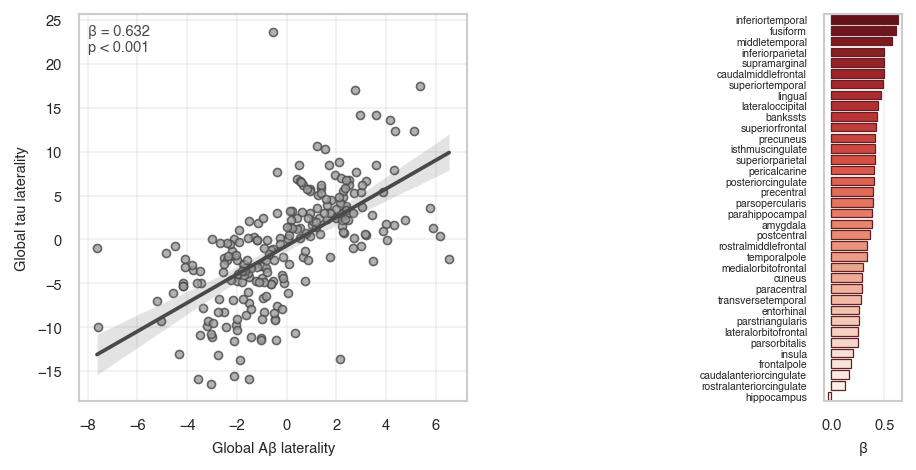

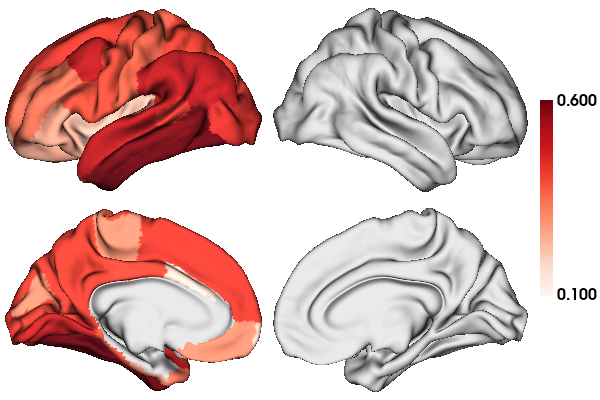

fdr-sig p-vals: min=0.0, mean=0.001, max=0.012
fdr-sig betas: min=0.167, mean=0.38, max=0.633


{'caudalanteriorcingulate': 0.167,
 'frontalpole': 0.185,
 'insula': 0.208,
 'parsorbitalis': 0.248,
 'lateralorbitofrontal': 0.248,
 'parstriangularis': 0.261,
 'entorhinal': 0.264,
 'transversetemporal': 0.275,
 'paracentral': 0.292,
 'cuneus': 0.293,
 'medialorbitofrontal': 0.299,
 'temporalpole': 0.334,
 'rostralmiddlefrontal': 0.336,
 'postcentral': 0.361,
 'Amygdala': 0.384,
 'parahippocampal': 0.384,
 'parsopercularis': 0.392,
 'precentral': 0.395,
 'posteriorcingulate': 0.401,
 'pericalcarine': 0.407,
 'superiorparietal': 0.411,
 'isthmuscingulate': 0.414,
 'precuneus': 0.414,
 'superiorfrontal': 0.424,
 'bankssts': 0.428,
 'lateraloccipital': 0.442,
 'lingual': 0.469,
 'superiortemporal': 0.492,
 'caudalmiddlefrontal': 0.495,
 'supramarginal': 0.495,
 'inferiorparietal': 0.496,
 'middletemporal': 0.571,
 'fusiform': 0.613,
 'inferiortemporal': 0.633}

{'L_inferiortemporal': 4.778637753539868e-25,
 'L_fusiform': 1.1258904741435419e-23,
 'L_middletemporal': 2.5188692298291307e-20,
 'L_superiortemporal': 8.603971651593626e-15,
 'L_caudalmiddlefrontal': 8.603971651593626e-15,
 'L_inferiorparietal': 8.603971651593626e-15,
 'L_supramarginal': 8.603971651593626e-15,
 'L_lingual': 2.8068059401096287e-13,
 'L_lateraloccipital': 8.398773195639625e-12,
 'L_bankssts': 4.3164307470349095e-11,
 'L_superiorfrontal': 4.696484989041676e-11,
 'L_isthmuscingulate': 1.7950539962541787e-10,
 'L_precuneus': 1.9375904948723213e-10,
 'L_superiorparietal': 2.1367485948614924e-10,
 'L_pericalcarine': 2.9468611794191904e-10,
 'L_posteriorcingulate': 4.630653004932309e-10,
 'L_precentral': 7.442217072683154e-10,
 'L_parsopercularis': 1.3707451192669362e-09,
 'L_parahippocampal': 2.5424125843389197e-09,
 'L_Amygdala': 2.8587793444679068e-09,
 'L_postcentral': 3.101806395783598e-08,
 'L_temporalpole': 2.663181481960039e-07,
 'L_rostralmiddlefrontal': 2.663181481

non-sig betas:


{'Hippocampus': -0.034, 'rostralanteriorcingulate': 0.13}

non-sig pvals:


{'rostralanteriorcingulate': 0.051, 'Hippocampus': 0.608}

In [2]:
set_plot_style(dpi=150)
grp_colors = {'LA': '#5785C1FF', 'S': '#D3D4D8FF', 'RA': '#FBA72AFF'}
statann_kwargs = dict(fontsize=7, color='#494949')
scatter_kwargs = dict(s=15, lw=0.8, alpha=0.8, edgecolor='#494949')
legend_kwargs = dict(loc='best', title='Tau asymmetry', title_fontsize=7)
strip_kwargs = dict(linewidth=0.8, size=3, alpha=0.8, edgecolor='#494949')
box_kwargs = dict(alpha=0.95, lw=0.8)
pval_kwargs = dict(lw=0.8, fontsize=7, col='#494949', h_coef=0.015, y_coef=0.1)

fig = plt.figure(figsize=(155.5/25.4, 80/25.4))
gs = fig.add_gridspec(1, 3, width_ratios=[5, 1, 1])
ax_left, ax_middle, ax_right = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

# subplot for regression between Ab vs tau lateralities

y = f'{tau_prefix}_global_LI'
ylabel = 'Global tau laterality'

x = f'{amy_prefix}_global_LI'
xlabel = 'Global Aβ laterality'

df_ = df.dropna(subset=[x, y])

covars = ['age', 'gender_baseline_variable']

_, ax_left, model = plot_regression(df=df_, x=x, y=y, covars=covars, standardise=True,
                               ax=ax_left, xlabel=xlabel, ylabel=ylabel, 
                               text_kwargs=statann_kwargs, scatter_kwargs=scatter_kwargs)
print(model.summary())

# empty subplot for surface plot

ax_middle.axis('off')

fnc_li_cols = [col for col in df.columns if ('LI' in col and 'fnc' in col and any(region in col for region in ROIs['global']))]
tnic_li_cols = [col for col in df.columns if ('LI' in col and 'tnic' in col and any(region in col for region in ROIs['global']))]

df_ = df.dropna(subset=fnc_li_cols+tnic_li_cols)

fnc_tnic_b = {}
for region in ROIs['global']:
    # find matching columns for the current region
    fnc_col = next((col for col in fnc_li_cols if region in col), None)
    tnic_col = next((col for col in tnic_li_cols if region in col), None)
    
    try:
        # prepare data and optionally z-score
        df_v = df_[[fnc_col, tnic_col] + ['age', 'gender_baseline_variable']]
        df_v = zscore(df_v)
        
        # OLS regression and extract the parameters for the main predictor
        model = sm.OLS(df_v[tnic_col], sm.add_constant(df_v[[fnc_col] + ['age', 'gender_baseline_variable']])).fit()
        b, pval = model.params[fnc_col], model.pvalues[fnc_col]
    except:
        b, pval = np.nan, np.nan
    fnc_tnic_b[region] = {'b': b, 'pval': pval}

# apply FDR correction
fnc_tnic_reg_fdr = fnc_tnic_b.copy()
non_nan_pvals = {region: info['pval'] for region, info in fnc_tnic_reg_fdr.items() if not np.isnan(info['pval'])}
_, pvals_fdr, _, _ = multipletests(list(non_nan_pvals.values()), alpha=0.05, method='fdr_bh')

for i, reg in enumerate(non_nan_pvals.keys()):
    fnc_tnic_reg_fdr[reg]['pval_fdr'] = pvals_fdr[i]

for reg, info in fnc_tnic_reg_fdr.items():
    if 'pval_fdr' not in info:
        fnc_tnic_reg_fdr[reg]['pval_fdr'] = np.nan

df_regs = pd.DataFrame(fnc_tnic_reg_fdr).T.dropna().reset_index().sort_values(by='b', ascending=False)
df_regs['index'] = df_regs['index'].str.lower()
fnc_tnic_reg_fdr_sb = {f"L_{region}": values['b'] for region, values in fnc_tnic_reg_fdr.items() if values['pval_fdr'] < 0.05}
fnc_tnic_reg_fdr_sp = {f"L_{region}": values['pval_fdr'] for region, values in fnc_tnic_reg_fdr.items() if values['pval_fdr'] < 0.05}

sns.barplot(df_regs, x='b', y='index', palette='Reds_r', linewidth=0.6, edgecolor='#651E24', ax=ax_right)
ax_right.tick_params(axis='y', labelsize=5)
ax_right.set_ylabel('')
ax_right.set_xlabel('β')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'OLS_ab_LI_tau_LI_global.pdf'), format='pdf', dpi=300)
plt.show()



# plot surface
export_kwargs = dict(nan_color=(0.8, 0.8, 0.8, 1), zoom=1.65, transparent_bg=False, scale=5)
embed_kwargs = dict(nan_color=(0.8, 0.8, 0.8, 1), zoom=1.65, transparent_bg=False, scale=1)
fig_args = dict(data=fnc_tnic_reg_fdr_sb, atlas='aparc', cmap='Reds', cmap_range=(0.1, 0.6), layout_style='grid')
fig_surf = plot_surface(**fig_args, plot_kwargs=embed_kwargs)
_ = plot_surface(**fig_args, plot_kwargs=export_kwargs, output=os.path.join(surfplot_dir, 'surf_ab_LI_tau_LI_betas.png'))
display(fig_surf)

sorted_betas = dict(sorted(fnc_tnic_reg_fdr_sb.items(), key=lambda x: x[1]))
sorted_pvals = dict(sorted(fnc_tnic_reg_fdr_sp.items(), key=lambda x: x[1]))
print(f"fdr-sig p-vals: min={round(np.min(list(sorted_pvals.values())), 6)}, "
      f"mean={round(np.mean(list(sorted_pvals.values())), 3)}, "
      f"max={round(np.max(list(sorted_pvals.values())), 3)}")
print(f"fdr-sig betas: min={round(np.min(list(sorted_betas.values())), 3)}, "
      f"mean={round(np.mean(list(sorted_betas.values())), 3)}, "
      f"max={round(np.max(list(sorted_betas.values())), 3)}")

sorted_betas_ = {k[2:]: round(v, 3) for k, v in sorted_betas.items()}
display(sorted_betas_)
display(sorted_pvals)

fnc_tnic_reg_fdr_nsb = {f"L_{region}": values['b'] for region, values in fnc_tnic_reg_fdr.items() if values['pval_fdr'] > 0.05}
sorted_ns_betas = dict(sorted(fnc_tnic_reg_fdr_nsb.items(), key=lambda x: x[1]))
fnc_tnic_reg_fdr_nsp = {f"L_{region}": values['pval_fdr'] for region, values in fnc_tnic_reg_fdr.items() if values['pval_fdr'] > 0.05}
sorted_ns_pvals = dict(sorted(fnc_tnic_reg_fdr_nsp.items(), key=lambda x: x[1]))

print('non-sig betas:')
sorted_ns_betas_ = {k[2:]: round(v, 3) for k, v in sorted_ns_betas.items()}
display(sorted_ns_betas_)

print('non-sig pvals:')
sorted_ns_pvals_ = {k[2:]: round(v, 3) for k, v in sorted_ns_pvals.items()}
display(sorted_ns_pvals_)

#### **Supplementary:** Associations between the laterality of Aβ and tau across different regions and meta-ROIs

Between tau laterality and Aβ laterality, an additional set of analyses was performed using
different meta-ROIs than used in the main analysis. First, the relationship between global tau
laterality and Aβ laterality at Ab staging meta-ROIs was assessed (Fig. S2.7a), which resulted
the strongest effect size at Intermediate-Ab meta-ROI (β=0.634, 95%CI=[0.533; 0.735],
pBonf<0.001) followed by Late-Ab (β=0.609, 95%CI=[0.505; 0.713], pBonf<0.001) and Early-
Ab (β=0.547, 95%CI=[0.438; 0.657], pBonf<0.001). Second, the association between global Ab
laterality and tau laterality at different Braak stages was investigated (Fig. S2.7b), with the
strongest effect found at Braak III-IV meta-ROI (β=0.655, 95%CI=[0.556; 0.754], pBonf<0.001)
followed by Braak V-VI (β=0.594, 95%CI=[0.488; 0.699], pBonf<0.001) and Braak I-II
(β=0.443, 95%CI=[0.327; 0.559], pBonf<0.001).

const_reg=global, reg:early_amyloid: b=0.547, 95%CI=[0.438, 0.657]


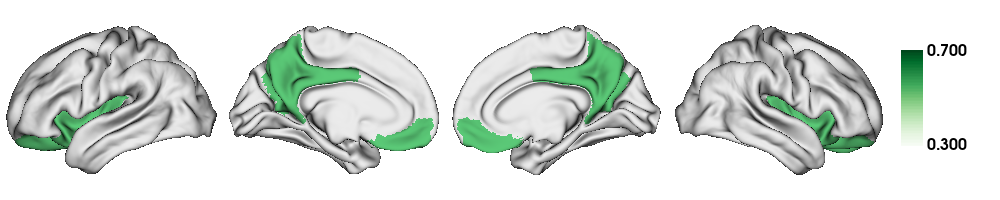

const_reg=global, reg:intermediate_amyloid: b=0.634, 95%CI=[0.533, 0.735]


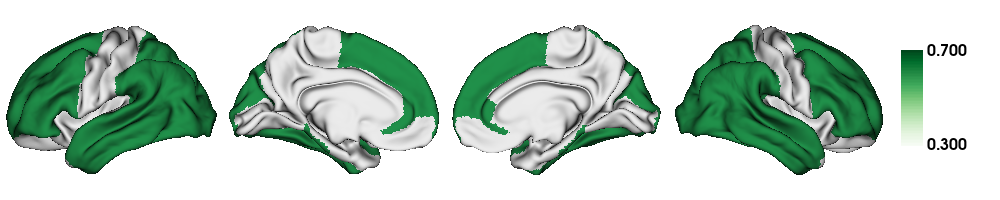

const_reg=global, reg:late_amyloid: b=0.609, 95%CI=[0.505, 0.713]


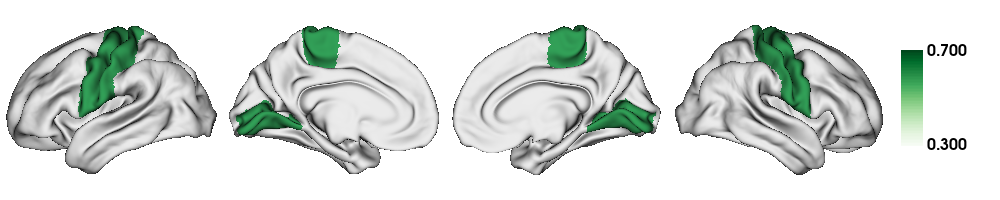

const_reg=global, reg:cho_com_I_II: b=0.443, 95%CI=[0.327, 0.559]


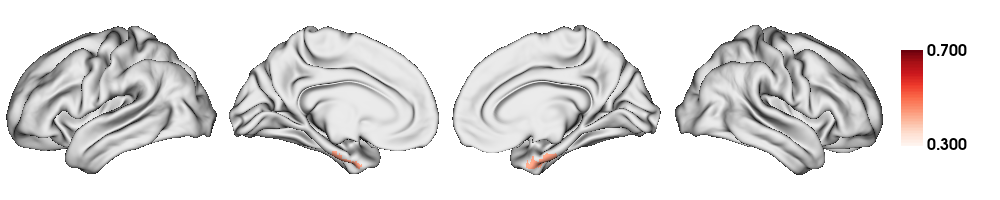

const_reg=global, reg:cho_com_III_IV: b=0.655, 95%CI=[0.556, 0.754]


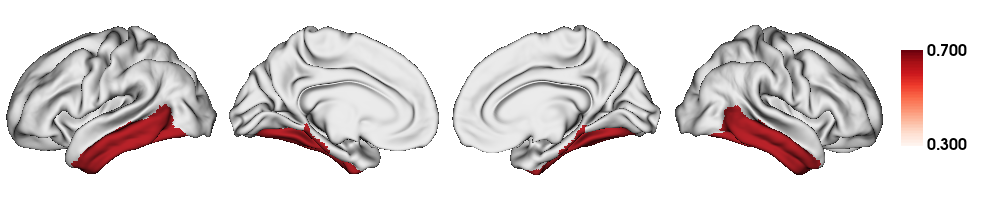

const_reg=global, reg:cho_com_V_VI: b=0.594, 95%CI=[0.488, 0.699]


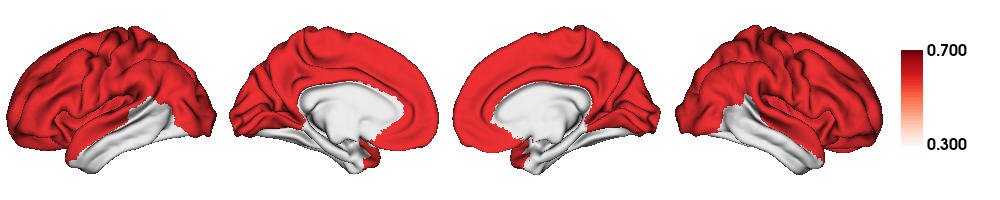

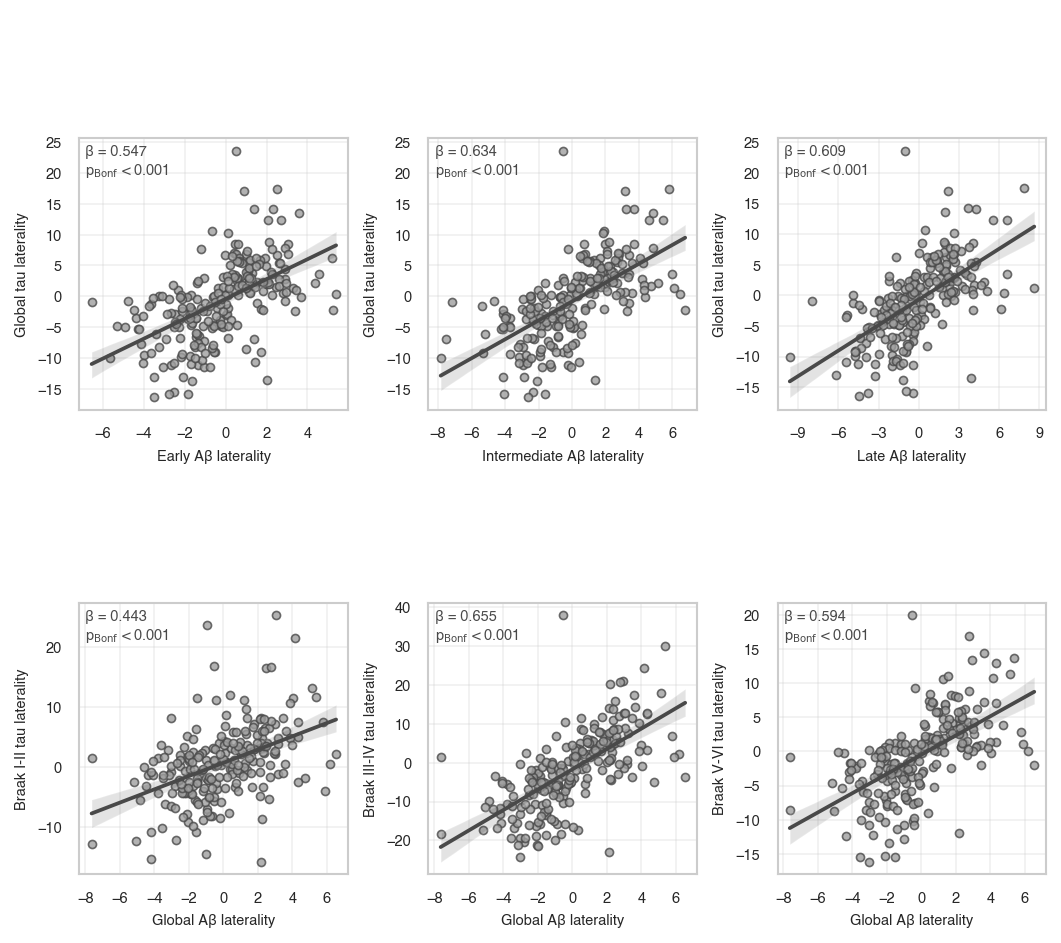

In [3]:
from matplotlib.ticker import MaxNLocator

set_plot_style(dpi=150)
statann_kwargs = dict(fontsize=7, color='#494949')
scatter_kwargs = dict(s=15, lw=0.8, alpha=0.8, edgecolor='#494949')
label_dict = {f'{tau_prefix}_temporal_meta_LI': 'Temporal tau laterality', f'{tau_prefix}_cho_com_I_II_LI': 'Braak I-II tau laterality', 
              f'{tau_prefix}_cho_com_III_IV_LI': 'Braak III-IV tau laterality', f'{tau_prefix}_cho_com_V_VI_LI': 'Braak V-VI tau laterality', 
              f'{amy_prefix}_temporal_meta_LI': 'Temporal Aβ laterality', f'{amy_prefix}_early_amyloid_LI': 'Early Aβ laterality', 
              f'{amy_prefix}_intermediate_amyloid_LI': 'Intermediate Aβ laterality', f'{amy_prefix}_late_amyloid_LI': 'Late Aβ laterality',
              f'{tau_prefix}_global_LI': 'Global tau laterality', f'{amy_prefix}_global_LI': 'Global Aβ laterality'}

for const_reg in ['global_LI']:

    reg_cols = {f'{tau_prefix}_{const_reg}': [f'{amy_prefix}_early_amyloid_LI', f'{amy_prefix}_intermediate_amyloid_LI', f'{amy_prefix}_late_amyloid_LI'],
                f'{amy_prefix}_{const_reg}': [f'{tau_prefix}_cho_com_I_II_LI', f'{tau_prefix}_cho_com_III_IV_LI', f'{tau_prefix}_cho_com_V_VI_LI']}

    df_ = df.dropna(subset=[f'{tau_prefix}_{const_reg}', f'{amy_prefix}_{const_reg}'])

    fig, axs = plt.subplots(4, 3, figsize=(180/25.4, 160/25.4), gridspec_kw={'height_ratios': [0.2, 1, 0.2, 1]})
    for j in range(3):
        axs[0, j].axis('off'), axs[2, j].axis('off')
    for i, (key_col, val_cols) in enumerate(reg_cols.items()):
        for j, val_col in enumerate(val_cols):
            # tau col on y-axis and ab col on x-axis
            if tau_prefix in key_col:
                x_col, y_col = val_col, key_col
            elif amy_prefix in key_col:
                x_col, y_col = key_col, val_col
            
            # plot in rows 1 and 3
            plot_row = 1 if i == 0 else 3
            _, axs[plot_row, j], mdl = plot_regression(df=df_, x=x_col, y=y_col, 
                                                    covars=['age', 'gender_baseline_variable'], 
                                                    standardise=True,
                                                    pval_multiplier=6,
                                                    ax=axs[plot_row, j], 
                                                    xlabel=label_dict[x_col], 
                                                    ylabel=label_dict[y_col],
                                                    text_kwargs=statann_kwargs, 
                                                    scatter_kwargs=scatter_kwargs)
            axs[plot_row, j].xaxis.set_major_locator(MaxNLocator(integer=True))
            
            roiname = val_col.split('_', 1)[1][:-3]
            b = mdl.params[x_col].round(3)
            ci = [mdl.conf_int().loc[x_col].iloc[0].round(3), 
                  mdl.conf_int().loc[x_col].iloc[1].round(3)]
            print(f'const_reg={const_reg[:-3]}, reg:{roiname}: b={b}, 95%CI={ci}')

            cmap = 'Greens' if plot_row == 1 else 'Reds'
            surf_args = dict(data=assign_val2roi(ROIs[roiname], b), atlas='aparc', cmap=cmap, cmap_range=(0.3, 0.7))
            fig_surf = plot_surface(**surf_args, plot_kwargs=dict(nan_color=(0.8, 0.8, 0.8, 1), zoom=1.35, transparent_bg=False, scale=1))
            _ = plot_surface(**surf_args, output=os.path.join(surfplot_dir, f'surf_{key_col}_with_{val_col}_beta.png'))
            display(fig_surf)
            

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'ext_OLS_ab_LI_tau_LI_rois_with_{const_reg}.pdf'), format='pdf', dpi=300)
    plt.show()

To examine the regional specificity of Ab-tau asymmetry relationships, we performed a
comprehensive pairwise region-by-region analysis between Aβ laterality and tau laterality (Fig.
S2.8). This analysis addressed whether associations between Aβ and tau distributions are
regionally specific (i.e., stronger within the same region) or reflect broader cross-regional
relationships. Notably, the strongest same-region associations occurred in the temporal lobe,
particularly the inferior temporal (b=0.633, pFDR<0.001), fusiform (b=0.613, pFDR<0.001), and
middle temporal (b=0.571, pFDR<0.001) gyri. Moreover, tau laterality in temporal regions
showed the strongest associations with Aβ laterality across the entire brain. Specifically, tau
laterality at inferior temporal gyrus demonstrated the highest average effect size with Aβ
laterality across all regions (bavg=0.428), followed by fusiform (bavg=0.405), and middle
temporal (bavg=0.405) gyri.

Ab means = [min=0.195, mean=0.297, max=0.364]
tau means = [min=0.176, mean=0.291, max=0.428]


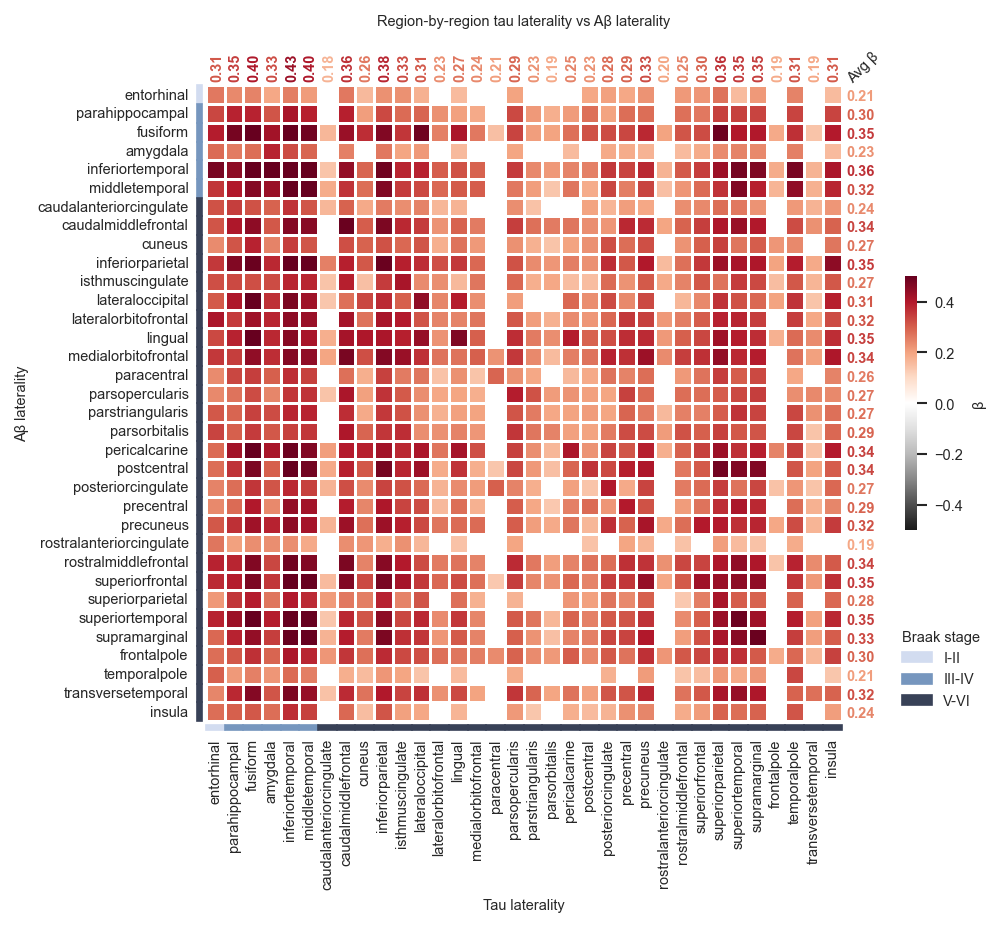

In [4]:
fnc_li_cols = [col for col in df.columns if ('LI' in col and 'fnc' in col and any(r in col for r in ROIs['global']))]
tnic_li_cols = [col for col in df.columns if ('LI' in col and 'tnic' in col and any(r in col for r in ROIs['global']))]

df_ = df[['mid', 'age', 'gender_baseline_variable'] + fnc_li_cols + tnic_li_cols].dropna()

results = []
for fnc_col in fnc_li_cols:
    for tnic_col in tnic_li_cols:
        fnc_region = next((r for r in ROIs['global'] if r in fnc_col), None)
        tnic_region = next((r for r in ROIs['global'] if r in tnic_col), None)
        if not (fnc_region and tnic_region):
            continue
        
        try:
            df_v = df_[[fnc_col, tnic_col, 'age', 'gender_baseline_variable']].dropna()
            df_v = pd.DataFrame(zscore(df_v), columns=df_v.columns)
            
            X = sm.add_constant(df_v[[fnc_col, 'age', 'gender_baseline_variable']])
            model = sm.OLS(df_v[tnic_col], X).fit()
            
            results.append({
                'fnc_region': fnc_region.lower(),
                'tnic_region': tnic_region.lower(),
                'b': model.params[fnc_col],
                'pval': model.pvalues[fnc_col]
            })
        except:
            results.append({
                'fnc_region': fnc_region.lower(),
                'tnic_region': tnic_region.lower(),
                'b': np.nan,
                'pval': np.nan
            })

df_results = pd.DataFrame(results)
df_agg = df_results.groupby(['fnc_region', 'tnic_region']).first().reset_index()

coefmat = df_agg.pivot(index='fnc_region', columns='tnic_region', values='b')
pvalmat = df_agg.pivot(index='fnc_region', columns='tnic_region', values='pval')

# FDR correction
pvals_flat = pvalmat.values.flatten()
non_nan = ~np.isnan(pvals_flat)
_, pvals_fdr, _, _ = multipletests(pvals_flat[non_nan], method='fdr_bh')
pvalmat_fdr = np.full_like(pvals_flat, np.nan)
pvalmat_fdr[non_nan] = pvals_fdr
pvalmat_fdr = pd.DataFrame(pvalmat_fdr.reshape(pvalmat.shape), 
                               index=pvalmat.index, 
                               columns=pvalmat.columns)

coefmat = coefmat.sort_index(axis=0).sort_index(axis=1)
pvalmat_fdr = pvalmat_fdr.sort_index(axis=0).sort_index(axis=1)

### plotting

set_plot_style(dpi=150)

braak_ROIs = {
    'I-II': ROIs['cho_com_I_II'], 
    'III-IV': ROIs['cho_com_III_IV'], 
    'V-VI': ROIs['cho_com_V_VI'],
}
braak_colors = {
    'I-II': '#D2DCF0FF',
    'III-IV': '#7696BEFF',
    'V-VI': '#384157FF',
    'Other': '#A7988DFF'
}
vmin, vmax = -0.5, 0.5

# mask non-significant associations
coefmat_f = coefmat.where(pvalmat_fdr < 0.05, np.nan)

# order regions by braak stages
ordered_regions = []
braak_stage_labels = []
for stage, regions in braak_ROIs.items():
    ordered_regions.extend([r.lower() for r in regions])
    braak_stage_labels.extend([stage] * len(regions))

# filter and reorder matrix
regions_in_matrix = set(coefmat_f.index) & set(coefmat_f.columns)
regions_to_use = [r for r in ordered_regions if r in regions_in_matrix]
coefmat_fo = coefmat_f.loc[regions_to_use, regions_to_use]

# map region to braak stages
region_to_braak = dict(zip(ordered_regions, braak_stage_labels))

# prepare Braak stage colors
bottom_colors = [braak_colors.get(region_to_braak[r], braak_colors['Other']) for r in coefmat_fo.index]
unique_stages = list(dict.fromkeys([region_to_braak[r] for r in coefmat_fo.index]))
legend_handles = [Patch(color=braak_colors[stage], label=stage) for stage in unique_stages]

### plotting

set_plot_style(dpi=150)
plt.figure(figsize=(180/25.4, 150/25.4))
sns.set_style('white')
ax = plt.gca()
ax.set_facecolor('white')
norm = plt.Normalize(vmin=vmin, vmax=vmax)

# heatmap
cbar = sns.heatmap(
    coefmat_fo, cmap='RdGy_r', center=0, square=True, linewidths=0.5,
    cbar_kws={'label': 'β', 'shrink': 0.4, 'aspect': 20, 'pad': 0.075},
    mask=coefmat_fo.isna(), vmin=vmin, vmax=vmax, norm=norm,
)

# plot beta averages for rows and columns
avgtxt_kwargs = dict(ha='center', va='center', fontsize=7, zorder=2, fontweight='bold')
ab_means = coefmat_fo.mean(axis=1)
for i, val in enumerate(ab_means):
    if not np.isnan(val):
        color = plt.cm.RdGy_r(norm(val))
        ax.text(coefmat_fo.shape[1] + 1, i + 0.6, f'{val:.2f}', color=color, **avgtxt_kwargs)
tau_means = coefmat_fo.mean(axis=0)
for j, val in enumerate(tau_means):
    if not np.isnan(val):
        color = plt.cm.RdGy_r(norm(val))
        ax.text(j + 0.6, -1, f'{val:.2f}', color=color, rotation=90, **avgtxt_kwargs)
ax.text(coefmat_fo.shape[1] + 0.2, 0, 'Avg β', rotation=45, 
        ha='left', va='bottom', fontsize=7)

# draw colored rectangles at axes for braak stages
for idx, color in enumerate(bottom_colors):
    kwargs = dict(color=color, transform=ax.transData, clip_on=False)
    ax.add_patch(plt.Rectangle((idx, coefmat_fo.shape[0]+0.2), 1, 0.3, **kwargs))
    ax.add_patch(plt.Rectangle((-0.5, idx), 0.3, 1, **kwargs))

print(f'Ab means = [min={ab_means.min():.3f}, mean={ab_means.mean():.3f}, max={ab_means.max():.3f}]')
print(f'tau means = [min={tau_means.min():.3f}, mean={tau_means.mean():.3f}, max={tau_means.max():.3f}]')

plt.xlabel('Tau laterality')
plt.ylabel('Aβ laterality')
plt.legend(handles=legend_handles, title='Braak stage', bbox_to_anchor=(1.075, 0), 
           title_fontsize=7, frameon=False, loc='lower left', alignment='left')
plt.title('Region-by-region tau laterality vs Aβ laterality', y=1.075)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'OLS_matrix_ab_li_tau_li_xs.pdf'), format='pdf', bbox_inches='tight', dpi=300)
plt.show()

# ab_means.sort_values(ascending=False).to_dict()
# tau_means.sort_values(ascending=False).to_dict()